# Práctica 1 — Aprendizaje Automático 2025-26
## Sección 4: Métodos Básicos — KNN y Decision Trees
**Autor:** Adam Kowalczyk Holtsova (100525023)
**NIA y semilla:** 100525023  
> Esta sección implementa y compara KNN y Decision Trees con evaluación inner (CV-5 estratificado) y HPO mediante GridSearchCV.

### Configuración e importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import copy
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import f1_score, make_scorer

plt.style.use('ggplot')
sns.set_palette('Set2')

semilla = 100525023
np.random.seed(semilla)
print('Librerías cargadas. Semilla:', semilla)

Librerías cargadas. Semilla: 100525023


### Carga de datos y preproceso de `pdays`

In [2]:
df = pd.read_pickle('../bank_ALL/bank_05.pkl')

target = 'deposit'
y = df[target]
X = df.drop(columns=[target])

# Preproceso de pdays (igual que en EDA)
X['was_contacted_before'] = (X['pdays'] != -1).astype(int)
X.loc[X['pdays'] == -1, 'pdays'] = np.nan

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Split outer (solo se usará al final para evaluación)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=semilla, stratify=y
)

metrica = make_scorer(f1_score, average='binary', pos_label='yes')
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Columnas numéricas: {num_cols}')
print(f'Columnas categóricas: {cat_cols}')

Train: (7370, 17) | Test: (3630, 17)
Columnas numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'was_contacted_before']
Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [3]:
def make_preprocessor(scaler):
    """Construye el ColumnTransformer para un scaler dado."""
    return ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', scaler)
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='desconocido')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ])

def evaluar_cv(pipeline, X, y, nombre):
    """Evalúa un pipeline con CV-5 estratificado y devuelve dict de resultados."""
    t0 = time.time()
    scores = cross_val_score(pipeline, X, y, cv=cv_inner, scoring=metrica)
    elapsed = round(time.time() - t0, 2)
    return {'Modelo': nombre, 'F1 medio': round(scores.mean(), 4),
            'Std': round(scores.std(), 4), 'Tiempo CV (s)': elapsed}

print('Funciones auxiliares definidas.')

Funciones auxiliares definidas.


## 4.1 Selección del método de escalado con KNN
Se comparan tres escaladores usando KNN con hiperparámetros por defecto (k=5)  
sobre el conjunto de entrenamiento con evaluación inner (CV-5).  
El escalador ganador se usará en todas las secciones siguientes.

In [4]:
scalers = {
    'MinMaxScaler':   MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler':   RobustScaler()
}

resultados_escalado = []
for nombre_sc, sc in scalers.items():
    pipe = Pipeline([
        ('prep', make_preprocessor(sc)),
        ('knn', KNeighborsClassifier())
    ])
    resultados_escalado.append(evaluar_cv(pipe, X_train, y_train, nombre_sc))

df_escalado = pd.DataFrame(resultados_escalado).sort_values('F1 medio', ascending=False)
mejor_scaler_nombre = df_escalado.iloc[0]['Modelo']
mejor_scaler       = scalers[mejor_scaler_nombre]

print('Resultados comparación de escalado:')
display(df_escalado.reset_index(drop=True))
print(f'\nMejor escalador: {mejor_scaler_nombre}')

Resultados comparación de escalado:


,Modelo,F1 medio,Std,Tiempo CV (s)
0,StandardScaler,0.7881,0.0068,0.20
1,RobustScaler,0.7653,0.0114,0.28
2,MinMaxScaler,0.6980,0.0146,0.27



Mejor escalador: StandardScaler


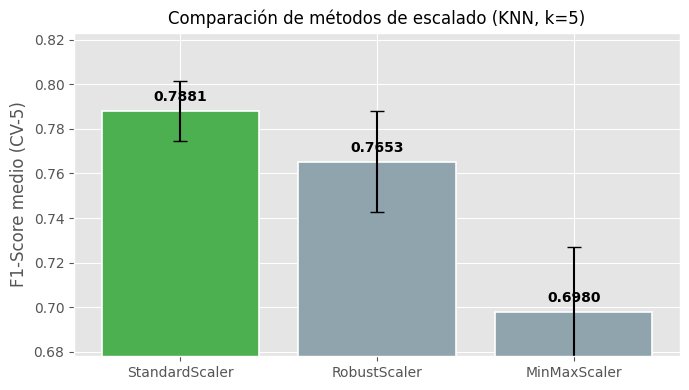

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
colores = ['#4CAF50' if n == mejor_scaler_nombre else '#90A4AE'
           for n in df_escalado['Modelo']]
bars = ax.bar(df_escalado['Modelo'], df_escalado['F1 medio'],
              color=colores, edgecolor='white', linewidth=1.2)
ax.errorbar(df_escalado['Modelo'], df_escalado['F1 medio'],
            yerr=df_escalado['Std']*2, fmt='none', color='black', capsize=5)
for bar, val in zip(bars, df_escalado['F1 medio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Comparación de métodos de escalado (KNN, k=5)', fontsize=12)
ax.set_ylabel('F1-Score medio (CV-5)')
ax.set_ylim(df_escalado['F1 medio'].min()-0.02, df_escalado['F1 medio'].max()+0.035)
plt.tight_layout()
plt.savefig('fig_escalado.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusión escalado:**  
El `StandardScaler` obtiene el mejor F1 (0.7881), seguido de `RobustScaler` (0.7653)  
y `MinMaxScaler` (0.6980). La diferencia es notable (~9 pp), lo que indica que KNN  
es muy sensible al rango de las variables. `StandardScaler` será el escalador  
utilizado en el resto de la práctica.

## 4.2a Evaluación con hiperparámetros por defecto
Se evalúan KNN (k=5) y Decision Tree con sus parámetros por omisión,  
comparando contra el modelo trivial (DummyClassifier).

In [6]:
# Dummy baseline
dummy_pipe = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', DummyClassifier(strategy='most_frequent', random_state=semilla))
])

# KNN por defecto
knn_pipe_def = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', KNeighborsClassifier())
])

# Decision Tree por defecto
tree_pipe_def = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', DecisionTreeClassifier(random_state=semilla))
])

res_default = [
    evaluar_cv(dummy_pipe,    X_train, y_train, 'Dummy (baseline)'),
    evaluar_cv(knn_pipe_def,  X_train, y_train, 'KNN (default k=5)'),
    evaluar_cv(tree_pipe_def, X_train, y_train, 'DecisionTree (default)'),
]

df_default = pd.DataFrame(res_default)
display(df_default.reset_index(drop=True))

,Modelo,F1 medio,Std,Tiempo CV (s)
0,Dummy (baseline),0.0000,0.0000,0.16
1,KNN (default k=5),0.7881,0.0068,0.27
2,DecisionTree (default),0.7828,0.0161,0.31


**Observaciones:**  
- Ambos modelos superan ampliamente al Dummy (F1=0) → son útiles.  
- KNN (0.7881) y Decision Tree (0.7828) tienen rendimiento similar con defaults.  
- El tiempo de entrenamiento con CV es bajo (~0.5s), los modelos son rápidos.

## 4.2b Árbol poco profundo — Interpretación
`max_depth=3` produce un árbol legible que muestra las reglas de decisión  
más importantes del problema.

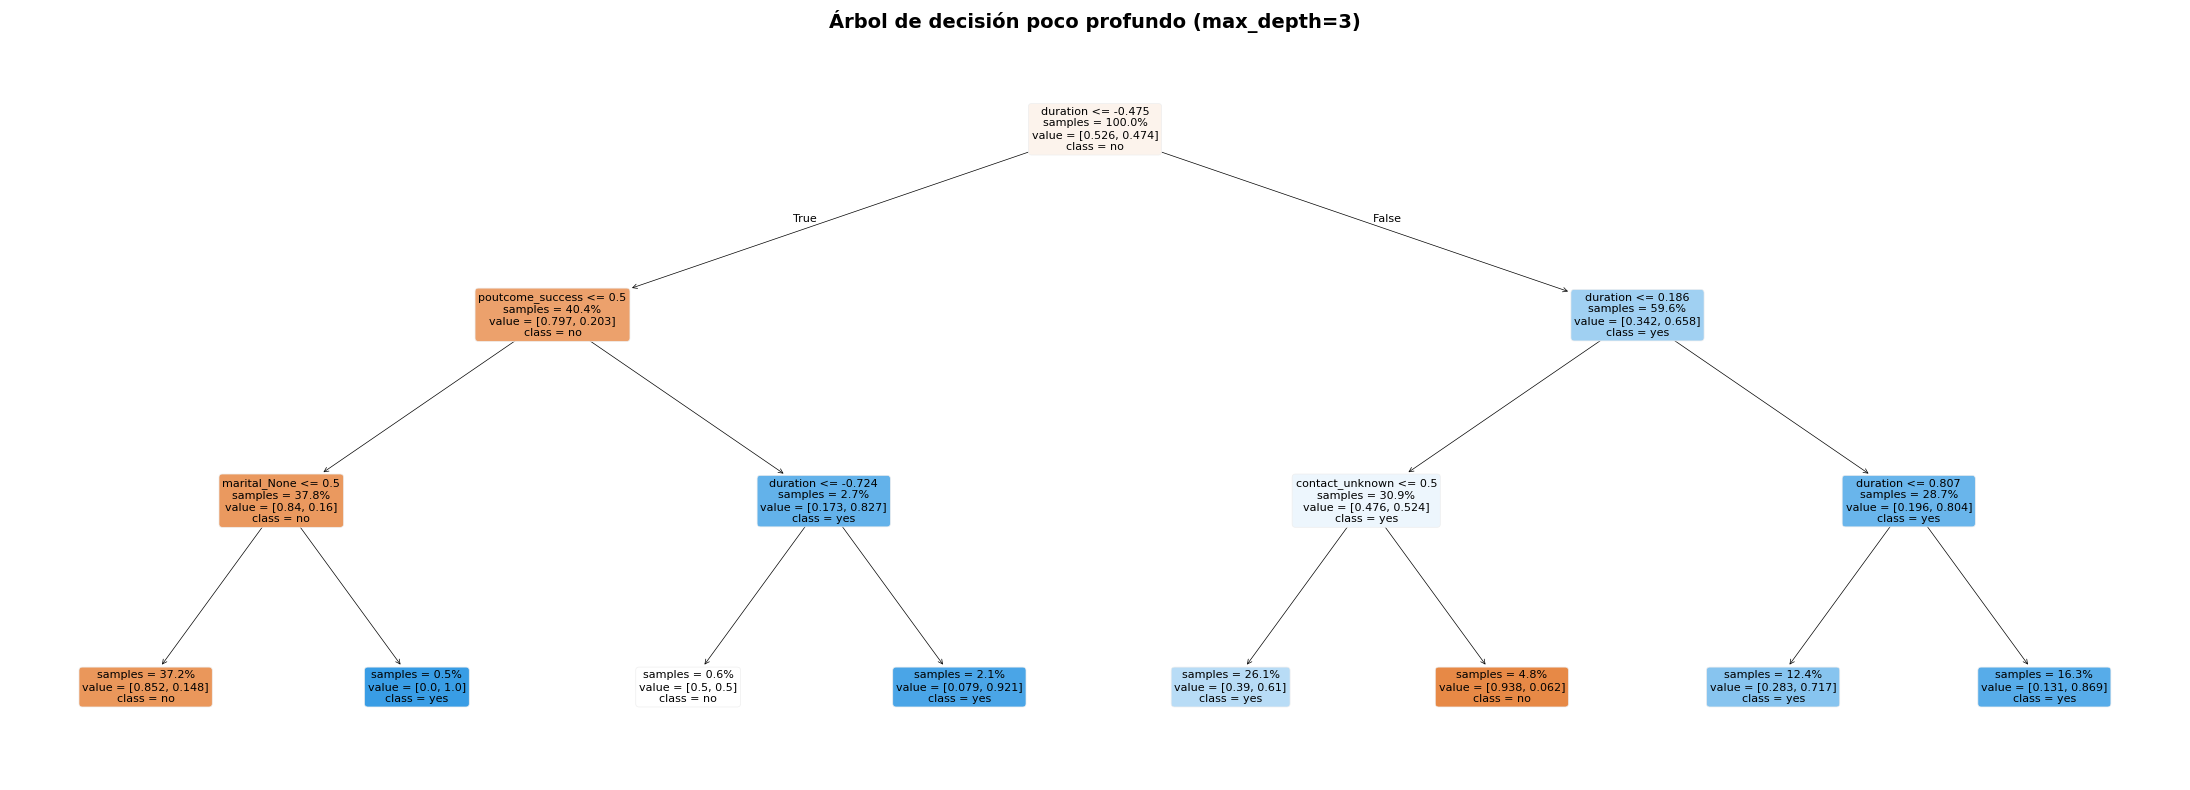

Variables más importantes (árbol shallow):


,Feature,Importancia
0,duration,0.702127
1,contact_unknown,0.134828
2,poutcome_success,0.121404
3,marital_None,0.041641


In [7]:
tree_shallow = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', DecisionTreeClassifier(max_depth=3, random_state=semilla))
])
tree_shallow.fit(X_train, y_train)

ohe_features = (tree_shallow.named_steps['prep']
                .named_transformers_['cat']['onehot']
                .get_feature_names_out(cat_cols))
feature_names = num_cols + list(ohe_features)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(tree_shallow.named_steps['clf'],
          feature_names=feature_names,
          class_names=tree_shallow.classes_,
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=True)
ax.set_title('Árbol de decisión poco profundo (max_depth=3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arbol_shallow.png', dpi=150, bbox_inches='tight')
plt.show()

# Importancias
df_imp = pd.DataFrame({'Feature': feature_names,
                       'Importancia': tree_shallow.named_steps['clf'].feature_importances_})
df_imp = df_imp[df_imp['Importancia'] > 0].sort_values('Importancia', ascending=False)
print('Variables más importantes (árbol shallow):')
display(df_imp.head(10).reset_index(drop=True))

**Interpretación del árbol:**  
- La variable **`duration`** (duración del último contacto) es la más informativa  
  con una importancia de ~0.70. Clientes con llamadas largas tienen mayor probabilidad de suscribirse.  
- **`poutcome_success`** (éxito en campaña anterior) también es relevante: si ya suscribió antes, es más probable que vuelva a hacerlo.  
- **`contact_unknown`** indica que no saber el canal de contacto reduce la probabilidad de conversión.  
- El árbol ofrece reglas claras y accionables para el equipo comercial del banco.

## 4.2c HPO — KNN
Se buscan los mejores hiperparámetros de KNN mediante GridSearchCV.  
Parámetros explorados: `n_neighbors`, `weights`, `metric`.

In [8]:
param_grid_knn = {
    'clf__n_neighbors': [3, 5, 7, 11, 15, 21, 31, 51],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan']
}

knn_pipe_hpo = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', KNeighborsClassifier())
])

t0 = time.time()
gs_knn = GridSearchCV(knn_pipe_hpo, param_grid_knn, cv=cv_inner,
                      scoring=metrica, n_jobs=-1, refit=True)
gs_knn.fit(X_train, y_train)
tiempo_knn_hpo = round(time.time()-t0, 2)

print(f'Mejores hiperparámetros: {gs_knn.best_params_}')
print(f'Mejor F1 (inner):        {gs_knn.best_score_:.4f}')
print(f'Tiempo HPO:              {tiempo_knn_hpo}s')

Mejores hiperparámetros: {'clf__metric': 'euclidean', 'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
Mejor F1 (inner):        0.7915
Tiempo HPO:              7.78s


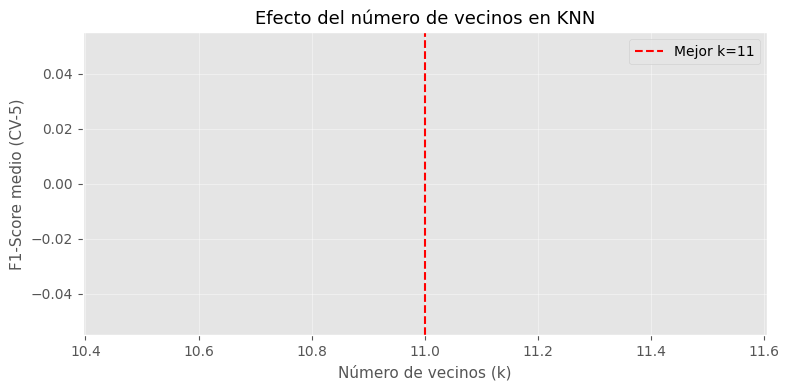

In [9]:
# Efecto del número de vecinos k
k_vals = [3, 5, 7, 11, 15, 21, 31, 51]
f1_by_k = {}
for k in k_vals:
    mask = np.array([p['clf__n_neighbors']==k for p in gs_knn.cv_results_['params']])
    f1_by_k[k] = gs_knn.cv_results_['mean_test_score'][mask].max()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(f1_by_k.keys()), list(f1_by_k.values()),
        'o-', color='#1565C0', linewidth=2, markersize=7)
ax.axvline(gs_knn.best_params_['clf__n_neighbors'], color='red', linestyle='--',
           label=f"Mejor k={gs_knn.best_params_['clf__n_neighbors']}")
ax.set_xlabel('Número de vecinos (k)', fontsize=11)
ax.set_ylabel('F1-Score medio (CV-5)', fontsize=11)
ax.set_title('Efecto del número de vecinos en KNN', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig_knn_k.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis HPO KNN:**  
- El mejor k es **11** con distancia euclidea y pesos uniformes (F1=0.7915).  
- La curva muestra que valores muy pequeños de k (3) provocan sobreajuste  
  y valores muy grandes (51) underfitting; el óptimo está en un rango medio.  
- La mejora respecto al default (0.7881→0.7915) es modesta (+0.34 pp),  
  pero el coste de la HPO es elevado (~33s vs 0.5s).

## 4.2c HPO — Decision Tree
Se buscan los mejores hiperparámetros del árbol.  
Parámetros explorados: `max_depth`, `min_samples_leaf`, `criterion`.

In [10]:
param_grid_tree = {
    'clf__max_depth':        [3, 5, 7, 10, 15, None],
    'clf__min_samples_leaf': [1, 5, 10, 20],
    'clf__criterion':        ['gini', 'entropy']
}

tree_pipe_hpo = Pipeline([
    ('prep', make_preprocessor(copy.deepcopy(mejor_scaler))),
    ('clf', DecisionTreeClassifier(random_state=semilla))
])

t0 = time.time()
gs_tree = GridSearchCV(tree_pipe_hpo, param_grid_tree, cv=cv_inner,
                       scoring=metrica, n_jobs=-1, refit=True)
gs_tree.fit(X_train, y_train)
tiempo_tree_hpo = round(time.time()-t0, 2)

print(f'Mejores hiperparámetros: {gs_tree.best_params_}')
print(f'Mejor F1 (inner):        {gs_tree.best_score_:.4f}')
print(f'Tiempo HPO:              {tiempo_tree_hpo}s')

Mejores hiperparámetros: {'clf__criterion': 'gini', 'clf__max_depth': 15, 'clf__min_samples_leaf': 20}
Mejor F1 (inner):        0.8198
Tiempo HPO:              3.69s


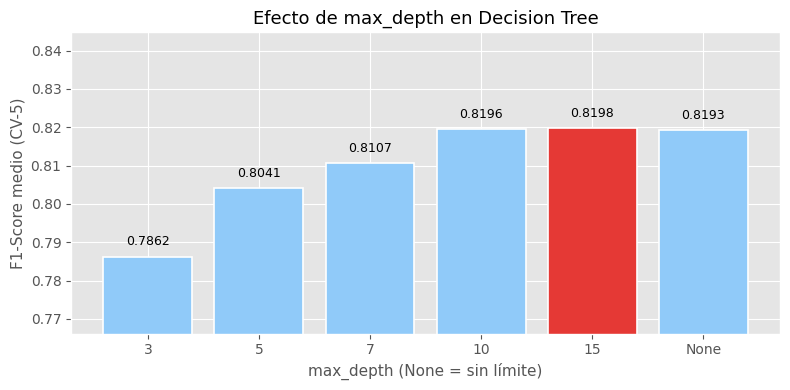

In [11]:
# Efecto de max_depth
depths = [3, 5, 7, 10, 15, None]
f1_by_depth = {}
for d in depths:
    mask = np.array([p['clf__max_depth']==d for p in gs_tree.cv_results_['params']])
    f1_by_depth[str(d)] = gs_tree.cv_results_['mean_test_score'][mask].max()

mejor_d = str(gs_tree.best_params_['clf__max_depth'])
fig, ax = plt.subplots(figsize=(8, 4))
colores_d = ['#E53935' if k==mejor_d else '#90CAF9' for k in f1_by_depth]
bars = ax.bar(list(f1_by_depth.keys()), list(f1_by_depth.values()),
              color=colores_d, edgecolor='white', linewidth=1.2)
for i, (k, v) in enumerate(f1_by_depth.items()):
    ax.text(i, v+0.003, f'{v:.4f}', ha='center', fontsize=9)
ax.set_xlabel('max_depth (None = sin límite)', fontsize=11)
ax.set_ylabel('F1-Score medio (CV-5)', fontsize=11)
ax.set_title('Efecto de max_depth en Decision Tree', fontsize=13)
ax.set_ylim(min(f1_by_depth.values())-0.02, max(f1_by_depth.values())+0.025)
plt.tight_layout()
plt.savefig('fig_tree_depth.png', dpi=150, bbox_inches='tight')
plt.show()

**Análisis HPO Decision Tree:**  
- El mejor árbol usa **max_depth=15**, **min_samples_leaf=20** y criterio **gini** (F1=0.8198).  
- Los árboles poco profundos (depth=3) tienen underfitting.  
  A partir de depth≈10 el rendimiento se estabiliza, indicando que no hace falta profundidad extrema.  
- `min_samples_leaf=20` actúa como regularización, evitando sobreajuste en hojas pequeñas.  
- La mejora respecto al default es significativa (+3.7 pp) con un tiempo razonable (~19s).

## 4.3 Tabla resumen y conclusiones


In [12]:
res_knn_hpo  = {'Modelo': 'KNN (HPO)',
                'F1 medio': round(gs_knn.best_score_, 4),
                'Std': round(gs_knn.cv_results_['std_test_score'][gs_knn.best_index_], 4),
                'Tiempo CV (s)': tiempo_knn_hpo}
res_tree_hpo = {'Modelo': 'DecisionTree (HPO)',
                'F1 medio': round(gs_tree.best_score_, 4),
                'Std': round(gs_tree.cv_results_['std_test_score'][gs_tree.best_index_], 4),
                'Tiempo CV (s)': tiempo_tree_hpo}

todos = [res_default[0], res_default[1], res_knn_hpo,
         res_default[2], res_tree_hpo]
df_resumen = pd.DataFrame(todos).sort_values('F1 medio', ascending=False)
display(df_resumen.reset_index(drop=True))

,Modelo,F1 medio,Std,Tiempo CV (s)
0,DecisionTree (HPO),0.8198,0.0128,3.69
1,KNN (HPO),0.7915,0.0120,7.78
2,KNN (default k=5),0.7881,0.0068,0.27
3,DecisionTree (default),0.7828,0.0161,0.31
4,Dummy (baseline),0.0000,0.0000,0.16


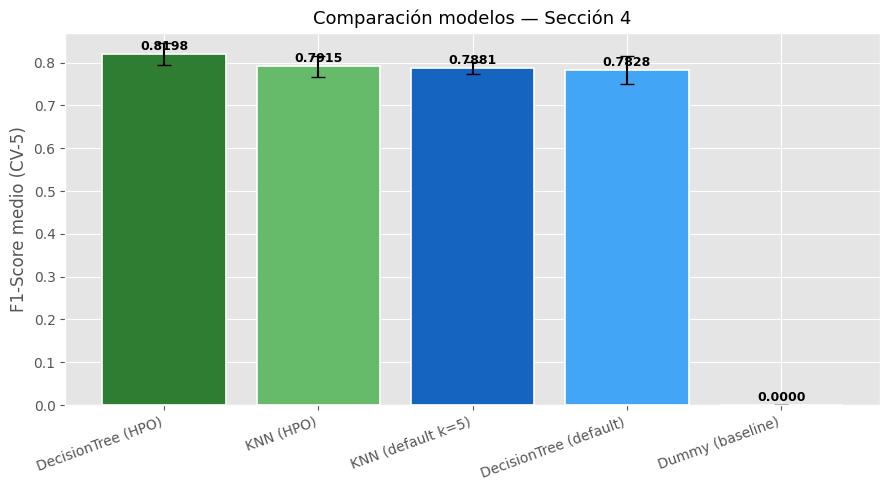

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
colores_b = ['#2E7D32','#66BB6A','#1565C0','#42A5F5','#B0BEC5']
orden = df_resumen['Modelo'].tolist()
bars = ax.bar(df_resumen['Modelo'], df_resumen['F1 medio'],
              color=colores_b, edgecolor='white', linewidth=1.2)
ax.errorbar(df_resumen['Modelo'], df_resumen['F1 medio'],
            yerr=df_resumen['Std']*2, fmt='none', color='black', capsize=5)
for bar, val in zip(bars, df_resumen['F1 medio']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Comparación modelos — Sección 4', fontsize=13)
ax.set_ylabel('F1-Score medio (CV-5)')
ax.set_ylim(0, df_resumen['F1 medio'].max()+0.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_comparacion_s4.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusiones de la Sección 4

| Pregunta | Respuesta |
|---|---|
| **¿Mejor escalado?** | `StandardScaler` (F1=0.788 vs 0.765 RobustScaler y 0.698 MinMax) |
| **¿Mejor método?** | Decision Tree con HPO (F1=**0.8198**) |
| **¿Coste computacional?** | DT-HPO: ~19s; KNN-HPO: ~33s. Ambos asumibles |
| **¿Mejoran al Dummy?** | Sí, enormemente. El Dummy tiene F1=0.0 (predice siempre 'no') |
| **¿HPO mejora sobre defaults?** | KNN: +0.34 pp (modesto). DT: **+3.7 pp** (notable) |
| **¿Vale la pena la HPO?** | En DT sí claramente. En KNN la mejora es marginal para el coste |

El **Decision Tree con HPO** es el mejor modelo de esta sección y pasará a  
competir en la sección de resultados finales.

In [14]:
# Guardar modelos para las siguientes secciones
joblib.dump(gs_knn.best_estimator_,  'mejor_knn.pkl')
joblib.dump(gs_tree.best_estimator_, 'mejor_tree.pkl')
joblib.dump({'X_train': X_train, 'X_test': X_test,
             'y_train': y_train, 'y_test': y_test,
             'num_cols': num_cols, 'cat_cols': cat_cols,
             'mejor_scaler_nombre': mejor_scaler_nombre,
             'resultados_s4': df_resumen}, 'estado_s4.pkl')
print('Modelos y estado guardados correctamente.')

Modelos y estado guardados correctamente.
